# Options and Derivatives

In [39]:
# packages
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime
from dateutil.relativedelta import relativedelta
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm

# Questions 1-5

In [40]:
def q1(K1, K2, p0, c0, s_min=40, s_max=160, n=1000):
    if K1 >= K2:
        raise ValueError("K1 must be less than K2.")

    S = np.linspace(s_min, s_max, n)
    payoff = np.maximum(K1 - S, 0) + np.maximum(S - K2, 0)
    profit = payoff - (p0 + c0)

    lower_be = K1 - (p0 + c0)
    upper_be = K2 + (p0 + c0)
    max_loss = p0 + c0

    print("Q1 Long Strangle")
    print(f"Lower break-even: {lower_be:.2f}")
    print(f"Upper break-even: {upper_be:.2f}")
    print(f"Maximum loss: {max_loss:.2f}")

    plt.figure(figsize=(8, 4.5))
    plt.plot(S, payoff, label="Payoff")
    plt.axvline(K1, linestyle="--", label="K1")
    plt.axvline(K2, linestyle="--", label="K2")
    plt.xlabel("Stock price at maturity")
    plt.ylabel("Payoff")
    plt.title("Long Strangle Payoff")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("q1_payoff.png", dpi=200)
    plt.close()

    plt.figure(figsize=(8, 4.5))
    plt.plot(S, profit, label="Profit")
    plt.axhline(0, linestyle="--", color="black")
    plt.axvline(K1, linestyle="--", label="K1")
    plt.axvline(K2, linestyle="--", label="K2")
    plt.scatter([lower_be, upper_be], [0, 0])
    plt.xlabel("Stock price at maturity")
    plt.ylabel("Profit")
    plt.title("Long Strangle Profit")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("q1_profit.png", dpi=200)
    plt.close()


def q2(S0, K, C0, P0, r, T):
    pv_k = K * math.exp(-r * T)
    implied_put = C0 + pv_k - S0
    mispricing = P0 - implied_put

    print("\nQ2 Put-Call Parity")
    print(f"PV(K): {pv_k:.4f}")
    print(f"Implied put price: {implied_put:.4f}")
    print(f"Actual put price: {P0:.4f}")

    if abs(mispricing) < 1e-10:
        print("Parity holds.")
    elif mispricing < 0:
        print(f"Put is underpriced by {-mispricing:.4f}")
    else:
        print(f"Put is overpriced by {mispricing:.4f}")


def q4(S0, u, d, r, K):
    R = 1 + r
    Su = S0 * u
    Sd = S0 * d

    q = (R * S0 - Sd) / (Su - Sd)

    Cu = max(Su - K, 0)
    Cd = max(Sd - K, 0)
    Pu = max(K - Su, 0)
    Pd = max(K - Sd, 0)

    C0 = (q * Cu + (1 - q) * Cd) / R
    P0 = (q * Pu + (1 - q) * Pd) / R

    delta_call = (Cu - Cd) / (Su - Sd)
    B_call = (Cd - delta_call * Sd) / R

    delta_put = (Pu - Pd) / (Su - Sd)
    B_put = (Pd - delta_put * Sd) / R

    print("\nQ4 One-Period Binomial")
    print(f"Risk-neutral probability q = {q:.4f}")
    print(f"Call price C0 = {C0:.4f}")
    print(f"Put price P0 = {P0:.4f}")
    print(f"Call replication: delta = {delta_call:.4f}, B = {B_call:.4f}")
    print(f"Put replication: delta = {delta_put:.4f}, B = {B_put:.4f}")
    print(f"Parity check: C0 + K/R = {C0 + K / R:.4f}, P0 + S0 = {P0 + S0:.4f}")


if __name__ == "__main__":
    q1(90, 110, 3.0, 2.5)
    q2(250, 235, 21.88, 5.25, 0.01, 90 / 365)
    q4(110, 1.1, 0.9, 0.05, 100)

Q1 Long Strangle
Lower break-even: 84.50
Upper break-even: 115.50
Maximum loss: 5.50

Q2 Put-Call Parity
PV(K): 234.4213
Implied put price: 6.3013
Actual put price: 5.2500
Put is underpriced by 1.0513

Q4 One-Period Binomial
Risk-neutral probability q = 0.7500
Call price C0 = 15.0000
Put price P0 = 0.2381
Call replication: delta = 0.9545, B = -90.0000
Put replication: delta = -0.0455, B = 5.2381
Parity check: C0 + K/R = 110.2381, P0 + S0 = 110.2381


# Question 6

## Data collection and cleaning

- Collect data about price of an option and its underlying stock.
- Denote the annualized, continuously-compounded return on the stock as normally distributed with mean $\mu$ and standard deviation $\sigma$ (estimate these, explaining your procedure).
- Assume that no dividends will be paid on the common stock over the next nine months.

In [41]:
# Chosen stock: Amazon
stock = yf.Ticker("AMZN")

# Collect historical data for the last year
hist_data = stock.history(period="1y", auto_adjust=True)

# Calculate daily continuously compounded returns and drop the first NaN
hist_data['Returns'] = np.log(hist_data['Close'] / hist_data['Close'].shift(1))
returns_clean = hist_data['Returns'].dropna()

# Estimate annualized mean (mu) and standard deviation/volatility (sigma)
trading_days = 252
mu = returns_clean.mean() * trading_days
sigma = returns_clean.std() * np.sqrt(trading_days)

# Get the most recent closing price and the exact date associated
current_price = hist_data['Close'].iloc[-1] 
as_of_date = hist_data.index[-1].date() 

print(f"--- Data Collection for AMZN ---")
print(f"As of Date: {as_of_date}")
print(f"Current Stock Price (S_t): {current_price:.2f}")
print(f"Estimated Annualized Mean Return (mu): {mu:.4f}")
print(f"Estimated Annualized Volatility (sigma): {sigma:.4f}")

--- Data Collection for AMZN ---
As of Date: 2026-03-06
Current Stock Price (S_t): 213.21
Estimated Annualized Mean Return (mu): 0.0683
Estimated Annualized Volatility (sigma): 0.3498


## Question 6 (a)

Find the per-period values of $u$, $d$, $r$, and $q$ for a three-period binomial which you might use to price a nine-month option.

In [42]:
# Question 6a ---

# Parameters
r = 0.04  # annualized, continuously-compounded risk-free rate (given)
T = 9 / 12 # time to maturity in years
n = 3 # periods/ no. of steps
h = T / n # time per period in years
disc = np.exp(-r * h) # discount factor
R = np.exp(r * h) #gross risk-free factor per step

# Calculate u, d, and q
u = np.exp(sigma * np.sqrt(h)) # up factor
d = np.exp(-sigma * np.sqrt(h)) # down factor
q = (R - d) / (u - d) # risk-neutral probability

print(f"\n--- Question 6a: Binomial Parameters ---")
print(f"Time step (h): {h:.4f}")
print(f"Up factor (u): {u:.4f}")
print(f"Down factor (d): {d:.4f}")
print(f"Annualized Risk-free rate (r): {r}")
print(f"Risk-neutral probability (q): {q:.4f}")

# Sanity check to ensure no-arbitrage conditions are met
if 0 < q < 1:
    print("Sanity Check: Passed (0 < q < 1). The binomial tree is arbitrage-free.")
else:
    print("Sanity Check: FAILED. q is not between 0 and 1. Check your volatility and time step parameters.")


--- Question 6a: Binomial Parameters ---
Time step (h): 0.2500
Up factor (u): 1.1911
Down factor (d): 0.8395
Annualized Risk-free rate (r): 0.04
Risk-neutral probability (q): 0.4850
Sanity Check: Passed (0 < q < 1). The binomial tree is arbitrage-free.


Find the nine-month option associated with the underlying stock. We have to:
- Identify the option with time-to-maturity nearest to 9 months
- Extract data on this option (ie. price)

In [43]:
# Matching the option expiry

options_expirations = list(stock.options)

if options_expirations:
    # 9 months is exactly 0.75 years. 0.75 * 365 = 273.75 days
    target_days = 273.75  
    
    valid_expirations = []
    for date_str in options_expirations:
        exp_date = datetime.strptime(date_str, "%Y-%m-%d").date()
        days_to_exp = (exp_date - as_of_date).days
        
        # Only consider future options
        if 0 < days_to_exp <= target_days: # Ensures the option has time to maturity < 9 months
            valid_expirations.append((date_str, days_to_exp))
            
    if valid_expirations:
        # Sort by absolute distance to 273.75 days
        valid_expirations.sort(key=lambda x: abs(x[1] - target_days))
        
        # Best match
        best_expiry, best_days = valid_expirations[0]
 
        print("\n--- Option Expirations ---")
        print(f"Targeting 9 months (~273.75 days) from {as_of_date}.")
        print(f"Selected expiration date: {best_expiry} ({best_days} days to expiry)")
        
        # Actual time to maturity in years for this specific option (useful for Q6b)
        actual_T = best_days / 365.0
        print(f"Actual Time to Maturity (T) in years: {actual_T:.4f}")
    else:
        print("\nNo valid future options data found.")
else:
    print("\nNo options data found.")

# Matching the strike price

options = stock.option_chain(best_expiry)
puts = options.puts

K_target = current_price  + 10
puts["strike_diff"] = abs(puts["strike"] - K_target)
selected_put = puts.loc[puts["strike_diff"].idxmin()]
market_price = (selected_put["bid"] + selected_put["ask"]) / 2
print("\n--- Option Price ---")
print("Target strike price:", K_target)
print("Actual strike price:", selected_put["strike"])
print("Market put price:", market_price)


--- Option Expirations ---
Targeting 9 months (~273.75 days) from 2026-03-06.
Selected expiration date: 2026-11-20 (259 days to expiry)
Actual Time to Maturity (T) in years: 0.7096

--- Option Price ---
Target strike price: 223.2100067138672
Actual strike price: 225.0
Market put price: 0.0


In [44]:
print("\n--- Selected Put ---")
selected_put


--- Selected Put ---


contractSymbol             AMZN261120P00225000
lastTradeDate        2026-03-06 20:30:05+00:00
strike                                   225.0
lastPrice                                 31.1
bid                                        0.0
ask                                        0.0
change                                     0.0
percentChange                              0.0
volume                                     1.0
openInterest                                 0
impliedVolatility                      0.00001
inTheMoney                                True
contractSize                           REGULAR
currency                                   USD
strike_diff                           1.789993
Name: 24, dtype: object

## Question 6 (b)
### Binomial model

Using a three-period binomial model to value a nine-month European put option on Amazon stock with a strike price of $S_t + 10$, as well as its replicating portfolio ($\Delta$ units of the asset and zero-coupon bond value $B$) at inception.

Please compare your results with the data (i.e. current market price). Explain the differences.

In [45]:
def binomial_put_price_and_replication(current_price, K):

    # Terminal stock prices
    S_T = np.array([current_price * (u**k) * (d**(n-k)) for k in range(n + 1)])
    
    # Terminal put payoffs
    V = np.maximum(K - S_T, 0)

    # Backward induction
    V_steps = [V]  # store option values from the back (step n down to 0)
    for step in range(n):
        V = disc * (q * V[1:] + (1 - q) * V[:-1])
        V_steps.append(V)

    # V_steps[-1] is step 0, V_steps[-2] is step 1
    P0 = float(V_steps[-1][0])
    step1_vals = V_steps[-2]  
    Pd, Pu = float(step1_vals[0]), float(step1_vals[1])

    # Replicating portfolio at inception
    Delta0 = (Pu - Pd) / (current_price * (u - d))
    B0 = (Pd - Delta0 * current_price * d) / np.exp(r * h)   # bond value today

    return P0, Delta0, B0, {"u": u, "d": d, "q": q, "dt": h, "Pu": Pu, "Pd": Pd}

In [46]:
K = current_price + 10       # strike as specified

P0, Delta0, B0, extras = binomial_put_price_and_replication(current_price, K)

print("Put price P0:", P0)
print("Delta0:", Delta0)
print("Bond position B0:", B0)
print("Check (Delta0*current_price + B0):", Delta0 * current_price + B0)

Put price P0: 29.42557930263373
Delta0: -0.47204468922637055
Bond position B0: 130.07023066183353
Check (Delta0*current_price + B0): 29.42557930263372


In [47]:
extras

{'u': np.float64(1.191138762363886),
 'd': np.float64(0.8395327493292556),
 'q': np.float64(0.4849672970129715),
 'dt': 0.25,
 'Pu': 11.495712754119172,
 'Pd': 46.882977351787815}

### Graph

In [48]:
def plot_combined_binomial_tree(S0, K, u, d, q, disc, n):
    # -----------------------------
    # 1. Build stock-price tree
    # -----------------------------
    stock_steps = []
    for step in range(n + 1):
        step_prices = []
        for down_moves in range(step + 1):
            up_moves = step - down_moves
            S = S0 * (u ** up_moves) * (d ** down_moves)
            step_prices.append(S)
        stock_steps.append(np.array(step_prices))

    # -----------------------------
    # 2. Build option-value tree
    # -----------------------------
    V = np.maximum(K - stock_steps[-1], 0)   # terminal put payoffs
    option_steps = [None] * (n + 1)
    option_steps[n] = V.copy()

    for step in range(n - 1, -1, -1):
        V = disc * (q * V[:step + 1] + (1 - q) * V[1:step + 2])
        option_steps[step] = V.copy()

    # -----------------------------
    # 3. Plot combined tree
    # -----------------------------
    fig, ax = plt.subplots(figsize=(4 * (n + 1), 2.2 * (n + 1)))

    node_positions = {}

    # Vertical spacing
    y_gap = 2.2

    # Create node positions
    for step in range(n + 1):
        for down_moves in range(step + 1):
            x = step
            y = (step - 2 * down_moves) * y_gap
            node_positions[(step, down_moves)] = (x, y)

    # Draw branches
    for step in range(n):
        for down_moves in range(step + 1):
            x1, y1 = node_positions[(step, down_moves)]

            # Up branch
            x2, y2 = node_positions[(step + 1, down_moves)]
            ax.plot([x1, x2], [y1, y2], linewidth=1.8)

            # Down branch
            x3, y3 = node_positions[(step + 1, down_moves + 1)]
            ax.plot([x1, x3], [y1, y3], linewidth=1.8)

    # Draw nodes and labels
    for step in range(n + 1):
        for down_moves in range(step + 1):
            x, y = node_positions[(step, down_moves)]
            S_val = stock_steps[step][down_moves]
            P_val = option_steps[step][down_moves]

            ax.scatter(x, y, s=900, zorder=3)

            label = f"S = {S_val:.2f}\nP = {P_val:.2f}"
            ax.text(
                x, y, label,
                ha='center', va='center',
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", lw=1.2),
                zorder=4
            )

    ax.set_title("Combined Binomial Tree: Stock Price and Put Value", fontsize=16, pad=20)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

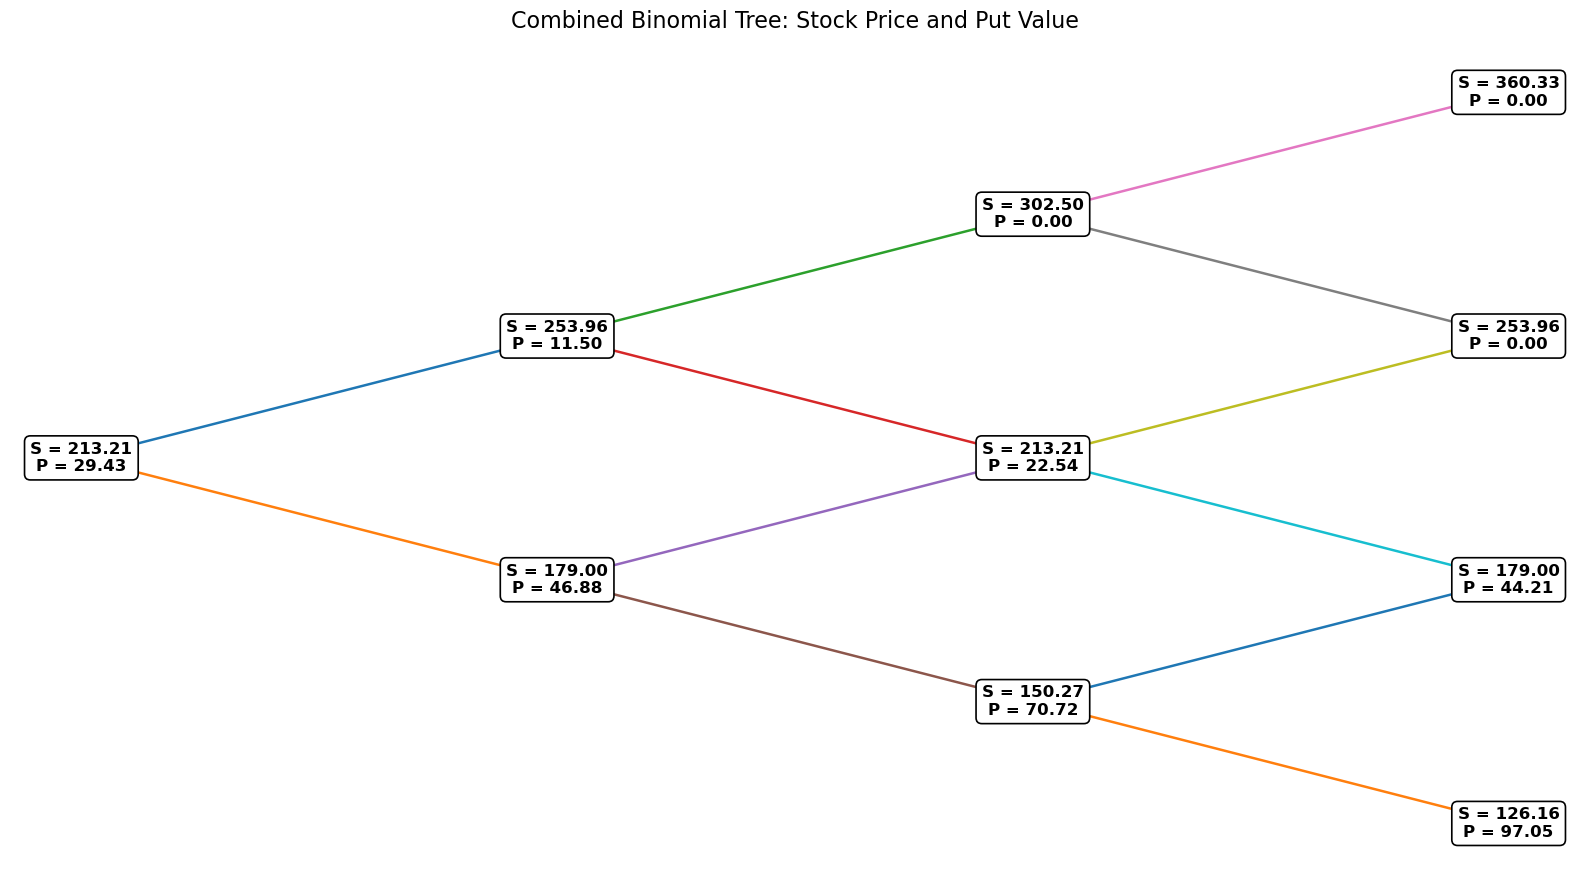

In [49]:
plot_combined_binomial_tree(current_price, K, u, d, q, disc, n)

## Question 6 (c)

Compute the present value of the physical expected payoff of the 3-step European put from the previous question. Recall that the physcial probability of an “up” move is given by $$p = 1/2 + 1/2*(\mu/\sigma)*\sqrt{h}.$$ Is the no-arbitrage
price more or less than the price we would get if we valued the payoffs this way? Does that make sense? 

In [50]:
def pv_physical_expected_put(current_price, K):

    # Physical up probability p (given)
    p = 0.5 + 0.5 * (mu / sigma) * np.sqrt(h)

    # Terminal nodes: k = number of up moves
    payoffs = []
    probs = []
    for k in range(n + 1):
        S_T = current_price * (u**k) * (d**(n - k))
        payoff = max(K - S_T, 0.0)
        prob = math.comb(n, k) * (p**k) * ((1 - p)**(n - k))
        payoffs.append(payoff)
        probs.append(prob)

    expected_payoff = float(np.dot(probs, payoffs))
    pv = np.exp(-r * T) * expected_payoff

    return pv, p, {"u": u, "d": d, "h": h, "K": K, "expected_payoff": expected_payoff}

pv_phys, p, info = pv_physical_expected_put(current_price, K)

print("Physical probability of an 'up' move:", p)
print("PV of physical expected payoff:", pv_phys)
print("Physical expected payoff at T:", info["expected_payoff"])
print("Put price from (b):", P0)

Physical probability of an 'up' move: 0.5487816081819878
PV of physical expected payoff: 23.034190270143363
Physical expected payoff at T: 23.73568579981721
Put price from (b): 29.42557930263373


If $\mu > 0.04$ (i.e., there is a positive equity risk premium), then $p > q$. 
This implies that under the physical measure the stock has a stronger upward drift, making the put less likely to finish in-the-money. As a result, the present value of the physical expected payoff is typically lower than the no-arbitrage price obtained from the risk-neutral binomial model. This is intuitive because option prices reflect risk-adjusted (risk-neutral) probabilities rather than the raw expected payoff under the physical distribution. Indeed, we have $$\text{PV of expected payoff (using physical probabilities)} < \text{Put price P0 (from risk-neutral binomial model)} $$

## Question 6 (d)

In [51]:
# --- Fixed seed for reproducibility ---
SEED = 42
np.random.seed(SEED)
print(f"Random seed set to: {SEED}")

# --- Parameters (inherited from earlier parts) ---
N        = 10_000          
S0       = current_price  
K        = S0 + 10        
r        = 0.04        
sigma    = sigma       
T        = 0.75        
barrier  = 1.2 * S0   

# Daily time step: 9 months x 20 trading days = 180 steps
trading_days_per_month = 20
n_steps  = 9 * trading_days_per_month   
dt       = T / n_steps             

print(f"\n--- Simulation Parameters ---")
print(f"S0      = {S0:.2f}")
print(f"Strike  = {K:.2f}")
print(f"Barrier = {barrier:.2f}  (= 1.2 x S0)")
print(f"Steps   = {n_steps} daily steps over {T} years (dt = {dt:.6f})")


Random seed set to: 42

--- Simulation Parameters ---
S0      = 213.21
Strike  = 223.21
Barrier = 255.85  (= 1.2 x S0)
Steps   = 180 daily steps over 0.75 years (dt = 0.004167)


In [52]:
# SIMULATION
# Geometric Brownian Motion daily step:
#   S(t+dt) = S(t) * exp((r - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
# where Z ~ N(0,1). We use risk-neutral drift (r) for pricing.
# Shape of Z: (n_steps, N) — each column is one full path

Z = np.random.standard_normal((n_steps, N))

# Build price paths via cumulative sum of log-returns
log_returns = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# Prepend S0 row so paths[0] = S0 for all paths
log_paths   = np.vstack([np.zeros(N), log_returns])    
price_paths = S0 * np.exp(np.cumsum(log_paths, axis=0))      

# --- Apply knock-out barrier ---
breached    = np.any(price_paths > barrier, axis=0)          
n_breached  = breached.sum()

# --- Compute payoffs ---
S_T         = price_paths[-1]                                 
put_payoffs = np.maximum(K - S_T, 0)                         
ko_payoffs  = np.where(breached, 0.0, put_payoffs) 

# --- Price: discount expected payoff under risk-neutral measure ---
discount          = np.exp(-r * T)
ko_price          = discount * ko_payoffs.mean()
ko_std            = ko_payoffs.std()

# 95% confidence interval: mean ± 1.96 * (std / sqrt(N))
ci_half           = 1.96 * ko_std / np.sqrt(N)
ci_lower          = ko_price - discount * ci_half  
ci_upper          = ko_price + discount * ci_half

print(f"\n--- Monte Carlo Results (N = {N:,}) ---")
print(f"Paths knocked out    : {n_breached:,} / {N:,}  ({100*n_breached/N:.1f}%)")
print(f"Knock-out put price  : ${ko_price:.4f}")
print(f"95% Confidence Interval: [${ko_price - discount*ci_half:.4f}, ${ko_price + discount*ci_half:.4f}]")
print(f"CI half-width        : ±${discount*ci_half:.4f}")


--- Monte Carlo Results (N = 10,000) ---
Paths knocked out    : 4,989 / 10,000  (49.9%)
Knock-out put price  : $24.1978
95% Confidence Interval: [$23.5419, $24.8537]
CI half-width        : ±$0.6559


In [58]:
# Paths that were knocked out (barrier breached)
knocked_out = np.max(price_paths, axis=0) >= barrier

# What the vanilla payoff would have been on those paths
vanilla_payoffs_all = np.maximum(K - price_paths[-1], 0)

# Lost payoffs = knocked out AND would have had positive payoff
lost_payoffs = vanilla_payoffs_all[knocked_out & (vanilla_payoffs_all > 0)]

# Vanilla Put — Monte Carlo price (same paths as KO)
vanilla_mc_price    = discount * vanilla_payoffs_all.mean()
vanilla_mc_std      = vanilla_payoffs_all.std()
vanilla_mc_ci_half  = 1.96 * vanilla_mc_std / np.sqrt(N)

print("--- Vanilla Put Monte Carlo vs Binomial ---")
print(f"Vanilla MC price    : ${vanilla_mc_price:.4f}")
print(f"Vanilla binomial P0 : ${P0:.4f}")
print(f"Difference          : ${abs(vanilla_mc_price - P0):.4f}")
print(f"95% CI              : [${vanilla_mc_price - discount*vanilla_mc_ci_half:.4f}, ${vanilla_mc_price + discount*vanilla_mc_ci_half:.4f}]")

print(f"\n--- Full Comparison ---")
print(f"Vanilla MC price    : ${vanilla_mc_price:.4f}")
print(f"KO put MC price     : ${ko_price:.4f}")
print(f"Difference          : ${vanilla_mc_price - ko_price:.4f}")
print(f"Value destroyed     : ${discount * lost_payoffs.sum() / N:.4f}")
print(f"These should be approx equal ↑")

--- Vanilla Put Monte Carlo vs Binomial ---
Vanilla MC price    : $28.0106
Vanilla binomial P0 : $29.4256
Difference          : $1.4149
95% CI              : [$27.3602, $28.6611]

--- Full Comparison ---
Vanilla MC price    : $28.0106
KO put MC price     : $24.1978
Difference          : $3.8128
Value destroyed     : $3.8128
These should be approx equal ↑


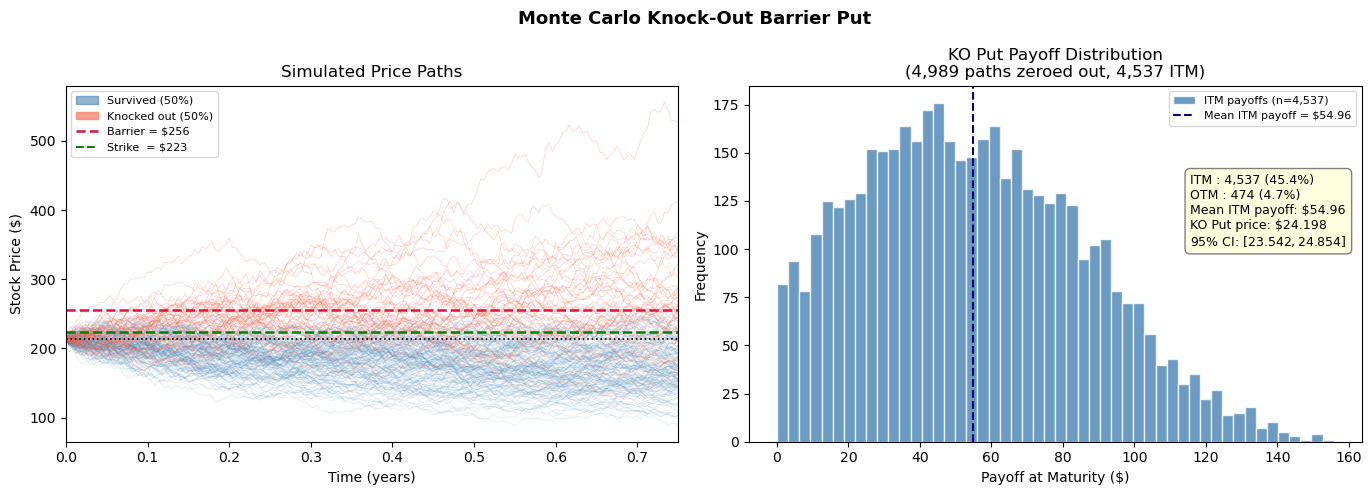

In [54]:
# FIGURE — Sample Price Paths + Payoff Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Monte Carlo Knock-Out Barrier Put", fontsize=13, fontweight='bold')

# --- Plot 1: Sample Paths ---
ax1 = axes[0]
t_axis = np.linspace(0, T, n_steps + 1)

survived_idx = np.where(~breached)[0][:150]
breached_idx = np.where(breached)[0][:50]

for i in survived_idx:
    ax1.plot(t_axis, price_paths[:, i], color='steelblue', alpha=0.15, linewidth=0.6)
for i in breached_idx:
    ax1.plot(t_axis, price_paths[:, i], color='tomato', alpha=0.25, linewidth=0.6)

ax1.axhline(barrier, color='crimson',    linestyle='--', linewidth=1.8, label=f'Barrier = ${barrier:.0f}')
ax1.axhline(K,       color='green', linestyle='--',  linewidth=1.8, label=f'Strike  = ${K:.0f}')
ax1.axhline(S0,      color='black',      linestyle=':',  linewidth=1.2, label=f'S0      = ${S0:.0f}')

blue_patch = mpatches.Patch(color='steelblue', alpha=0.6, label=f'Survived ({100*(1-n_breached/N):.0f}%)')
red_patch  = mpatches.Patch(color='tomato',    alpha=0.6, label=f'Knocked out ({100*n_breached/N:.0f}%)')
ax1.legend(handles=[blue_patch, red_patch,
                    plt.Line2D([0],[0], color='crimson',    linestyle='--', linewidth=1.8),
                    plt.Line2D([0],[0], color='green', linestyle='--',  linewidth=1.5)],
           labels=[f'Survived ({100*(1-n_breached/N):.0f}%)',
                   f'Knocked out ({100*n_breached/N:.0f}%)',
                   f'Barrier = ${barrier:.0f}',
                   f'Strike  = ${K:.0f}'],
           fontsize=8, loc='upper left')
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Stock Price ($)")
ax1.set_title("Simulated Price Paths")
ax1.set_xlim(0, T)


# --- Plot 2: Payoff Distribution ---
ax2 = axes[1]
nonzero_payoffs = ko_payoffs[ko_payoffs > 0]

ax2.hist(nonzero_payoffs, bins=50, color='steelblue', edgecolor='white',
         alpha=0.8, label=f'ITM payoffs (n={len(nonzero_payoffs):,})')

mean_itm = nonzero_payoffs.mean() if len(nonzero_payoffs) > 0 else 0
ax2.axvline(mean_itm, color='navy', linestyle='--',
            linewidth=1.5, label=f'Mean ITM payoff = ${mean_itm:.2f}')

ax2.text(0.72, 0.55,
         f"ITM : {len(nonzero_payoffs):,} ({100*len(nonzero_payoffs)/N:.1f}%)\n"
         f"OTM : {int(np.sum((~breached) & (ko_payoffs == 0))):,} ({100*np.sum((~breached) & (ko_payoffs == 0))/N:.1f}%)\n"
         f"Mean ITM payoff: ${mean_itm:.2f}\n"
         f"KO Put price: ${ko_price:.3f}\n"
         f"95% CI: [${ko_price - discount*ci_half:.3f}, ${ko_price + discount*ci_half:.3f}]",
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

ax2.set_xlabel("Payoff at Maturity ($)")
ax2.set_ylabel("Frequency")
ax2.set_title(f"KO Put Payoff Distribution\n({n_breached:,} paths zeroed out, {len(nonzero_payoffs):,} ITM)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [55]:
# How many KO paths would have been ITM under a vanilla put?

# Vanilla ITM: S_T < K regardless of barrier
vanilla_itm  = price_paths[-1] < K

# Breakdown
ko_and_itm   = breached  & vanilla_itm   # knocked out but would have been ITM
survived_itm = ~breached & vanilla_itm   # survived and ITM
survived_otm = ~breached & ~vanilla_itm  # survived and OTM
ko_and_otm   = breached  & ~vanilla_itm  # knocked out and would have been OTM

print("--- Vanilla vs Knock-Out Comparison ---")
print(f"Total paths                          : {N:,}")

print(f"\nSurvived + ITM (earn payoff)         : {survived_itm.sum():,}  ({100*survived_itm.mean():.1f}%)")
print(f"Survived + OTM (no payoff)           : {survived_otm.sum():,}  ({100*survived_otm.mean():.1f}%)")
print(f"Knocked out + would have been ITM    : {ko_and_itm.sum():,}  ({100*ko_and_itm.mean():.1f}%)")
print(f"Knocked out + would have been OTM    : {ko_and_otm.sum():,}  ({100*ko_and_otm.mean():.1f}%)")

print(f"\nTotal ITM under vanilla              : {vanilla_itm.sum():,}  ({100*vanilla_itm.mean():.1f}%)")
print(f"ITM lost due to barrier              : {ko_and_itm.sum():,}  ({100*ko_and_itm.mean():.1f}%)")
print("  → These are the paths the barrier kills that actually mattered")

# Lost value due to barrier
lost_payoffs = np.maximum(K - price_paths[-1], 0)[ko_and_itm]
value_destroyed = discount * lost_payoffs.sum() / N

print(f"\nMean payoff lost per knocked-out ITM path : ${lost_payoffs.mean():.4f}")
print(f"Total expected value destroyed by barrier : ${value_destroyed:.4f}")
print(f"Vanilla MC price - KO MC price            : ${vanilla_mc_price - ko_price:.4f}")
print("  → These two numbers should match (up to rounding)")
print(f"  → This is exactly why KO put (${ko_price:.4f}) < Vanilla MC put (${vanilla_mc_price:.4f})")

--- Vanilla vs Knock-Out Comparison ---
Total paths                          : 10,000

Survived + ITM (earn payoff)         : 4,537  (45.4%)
Survived + OTM (no payoff)           : 474  (4.7%)
Knocked out + would have been ITM    : 1,293  (12.9%)
Knocked out + would have been OTM    : 3,696  (37.0%)

Total ITM under vanilla              : 5,830  (58.3%)
ITM lost due to barrier              : 1,293  (12.9%)
  → These are the paths the barrier kills that actually mattered

Mean payoff lost per knocked-out ITM path : $30.3864
Total expected value destroyed by barrier : $3.8128
Vanilla MC price - KO MC price            : $3.8128
  → These two numbers should match (up to rounding)
  → This is exactly why KO put ($24.1978) < Vanilla MC put ($28.0106)


## Question 6 (e)

In [56]:
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

print("--- Vanilla Put Used as Control Variate ---")
print(f"S0                   : ${S0:.4f}")
print(f"K                    : ${K:.4f}")
print(f"T                    : {T}")
print(f"sigma                : {sigma:.6f}")
print(f"r                    : {r}")
print(f"Black-Scholes price   : ${bs_price:.4f}")
print(f"Vanilla MC price      : ${vanilla_mc_price:.4f}")
print(f"Absolute difference   : ${abs(vanilla_mc_price - bs_price):.4f}")

--- Vanilla Put Used as Control Variate ---
S0                   : $213.2100
K                    : $223.2100
T                    : 0.75
sigma                : 0.349820
r                    : 0.04
Black-Scholes price   : $27.6120
Vanilla MC price      : $28.0106
Absolute difference   : $0.3986


In [57]:
# Discounted vanilla and KO payoffs on the SAME simulated paths
vanilla_payoffs_cv = discount * np.maximum(K - price_paths[-1], 0)
ko_payoffs_cv      = discount * ko_payoffs

# Optimal control variate coefficient
cov_matrix = np.cov(ko_payoffs_cv, vanilla_payoffs_cv)
beta       = cov_matrix[0, 1] / cov_matrix[1, 1]

# Control variate estimator, anchored on the Black–Scholes vanilla put price
ko_cv = ko_payoffs_cv - beta * (vanilla_payoffs_cv - bs_price)

# CV price and 95% CI
ko_cv_price = ko_cv.mean()
ci_half_cv  = 1.96 * ko_cv.std(ddof=1) / np.sqrt(N)
ci_lower_cv = ko_cv_price - ci_half_cv
ci_upper_cv = ko_cv_price + ci_half_cv

# Diagnostics
corr = np.corrcoef(ko_payoffs_cv, vanilla_payoffs_cv)[0, 1]
var_reduction = 100 * (1 - ko_cv.var(ddof=1) / ko_payoffs_cv.var(ddof=1))

# Plain MC CI width from Q6(d)
ci_width_plain = ci_upper - ci_lower
ci_width_cv    = ci_upper_cv - ci_lower_cv

print("---Control Variate Results ---")
print(f"Correlation(KO, Vanilla) : {corr:.4f}")
print(f"Beta (CV coefficient)    : {beta:.4f}")
print(f"KO Put price (plain MC)  : ${ko_price:.4f}")
print(f"KO Put price (CV)        : ${ko_cv_price:.4f}")
print(f"95% CI (plain MC)        : [${ci_lower:.4f}, ${ci_upper:.4f}]")
print(f"95% CI (CV)              : [${ci_lower_cv:.4f}, ${ci_upper_cv:.4f}]")
print(f"CI width (plain MC)      : ${ci_width_plain:.4f}")
print(f"CI width (CV)            : ${ci_width_cv:.4f}")
print(f"Variance reduction       : {var_reduction:.2f}%")

---Control Variate Results ---
Correlation(KO, Vanilla) : 0.9253
Beta (CV coefficient)    : 0.9330
KO Put price (plain MC)  : $24.1978
KO Put price (CV)        : $23.8259
95% CI (plain MC)        : [$23.5419, $24.8537]
95% CI (CV)              : [$23.5771, $24.0747]
CI width (plain MC)      : $1.3117
CI width (CV)            : $0.4976
Variance reduction       : 85.61%
